# MT Mount Characterization

This notebook analyzes the characterization of the MT Mount using telemetry data. It identifies slew and settle times, computes RMS jitter values in azimuth and elevation. The notebook includes visualizations of tracking performance and RMS jitter histograms for a set of slews.

Authors:  
- Craig Lage (Original Code)  
- Last edited by Laura Toribio (20-May-25)  


In [12]:
import asyncio
import glob
import os
import sys
import time
import pickle as pkl

import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time, TimeDelta

from lsst.summit.utils.efdUtils import getEfdData, makeEfdClient

##  Get all of the data for the selected times

In [13]:
# Create an EFD client instance
client = makeEfdClient()

The time is defined using the `Time` class from `astropy`, which follows the ISO 8601 format:  

**YYYY-MM-DD HH:MM:SSZ**, where:  
- `YYYY` is the year  
- `MM` is the month  
- `DD` is the day  
- `HH:MM:SS` represents hours, minutes, and seconds in 24-hour format  
- `Z` indicates that the time is in Coordinated Universal Time (UTC)  

In [14]:
# Define the time range using UTC format
start = Time("2023-01-26T06:51:00", scale='utc')
end = Time("2023-01-26T09:50:00", scale='utc')

In [15]:
# Query azimuth and elevation telemetry data
az = await client.select_time_series(
    'lsst.sal.MTMount.azimuth',
    ['actualPosition', 'timestamp'],  
    start, 
    end
)

el = await client.select_time_series(
    'lsst.sal.MTMount.elevation',
     ['actualPosition', 'timestamp'],  
    start,
    end
)

# Query commanded track target data
az_track = await client.select_time_series(
    'lsst.sal.MTMount.command_trackTarget',
    ['azimuth', 'taiTime'],  
    start, 
    end
)

el_track = await client.select_time_series(
    'lsst.sal.MTMount.command_trackTarget',
    ['elevation', 'taiTime'], 
    start,
    end
)

# Query azimuth and elevation "in position" events
az_pos = await client.select_time_series(
    'lsst.sal.MTMount.logevent_azimuthInPosition',
    ['inPosition', 'private_kafkaStamp'],  
    start, 
    end
)

az_pos = az_pos[az_pos['inPosition']] # Select only the True values

el_pos = await client.select_time_series(
    'lsst.sal.MTMount.logevent_elevationInPosition',
    ['inPosition', 'private_kafkaStamp'], 
    start,
    end
)

el_pos = el_pos[el_pos['inPosition']] # Select only the True values


In [16]:
# Length of Azimuth and Elevation Track Target Data
print(len(az_track), len(el_track))

204221 204221


In [17]:
# Length of Azimuth and Elevation Position Data
print(len(az_pos), len(el_pos))

225 225


<Axes: >

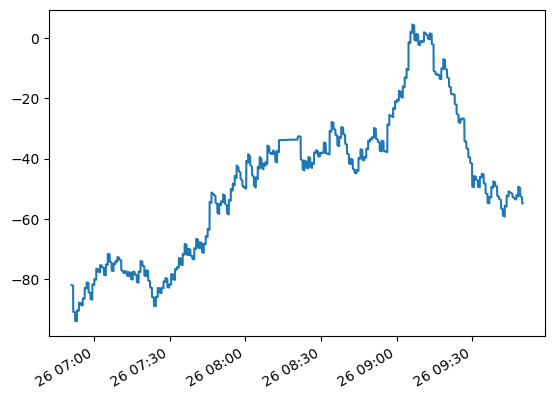

In [18]:
az['actualPosition'].plot()

In [19]:
# Start with start_slew times
azs = az_track.values[:, 0]
els = el_track.values[:, 0]
times = az_track.values[:, 1]

start_slew_times_1 = []
slew_dist_1 = []
slew_times_1 = []

for i in range(1, len(az_track)):
    az_shift = abs(azs[i] - azs[i - 1])
    el_shift = abs(els[i] - els[i - 1])

    if az_shift > 0.1 or el_shift > 0.1:
        start_slew_times_1.append(times[i])

        az_shift_mod = az_shift * np.cos(np.radians(els[i]))
        shift = np.sqrt(el_shift**2 + az_shift_mod**2)
        slew_dist_1.append(shift)

print(f"Number of start slew times detected: {len(start_slew_times_1)}")

# Collect timestamps when the mount is reported to be in position
in_pos_1 = []

az_pos_values = az_pos.values[:, 1]
el_pos_values = el_pos.values[:, 1]

for i in range(len(az_pos)):
    in_pos_1.append(max(az_pos_values[i], el_pos_values[i]))

print(f"Number of in-position timestamps: {len(in_pos_1)}")

# Now pair them up
pair_min = 1.0   # Minimum time difference (s)
pair_max = 6.0   # Maximum time difference (s)

start_slew_times = []
slew_dist = []
slew_times = []
in_pos = []

for start_time in start_slew_times_1:
    for pos_time in in_pos_1:
        delta_t = pos_time - start_time

        if pair_min < delta_t < pair_max:
            in_pos.append(pos_time)
            start_slew_times.append(start_time)
            slew_times.append(delta_t)
            index = start_slew_times_1.index(start_time)
            slew_dist.append(slew_dist_1[index])


print(
    f"Paired events — In Position: {len(in_pos)}, "
    f"Start Slews: {len(start_slew_times)}, "
    f"Slew Times: {len(slew_times)}, "
    f"Slew Distances: {len(slew_dist)}"
)

Number of start slew times detected: 224
Number of in-position timestamps: 225
Paired events — In Position: 223, Start Slews: 223, Slew Times: 223, Slew Distances: 223


# Plots of MTMount characterization 

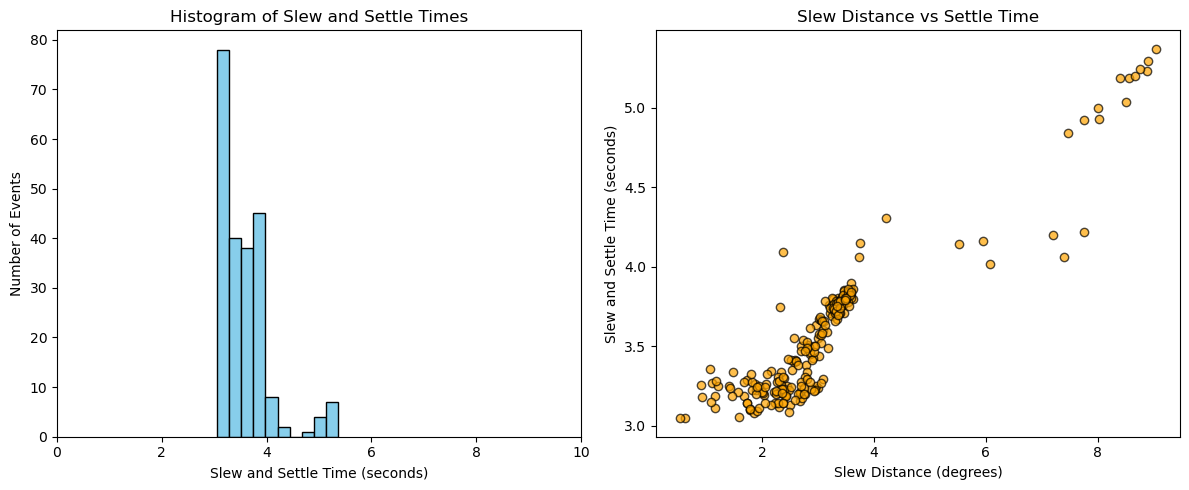

In [31]:
# Plot Slew and settle time (in seconds)
plt.figure(figsize=(12, 5))
plt.subplots_adjust(wspace=0.4)

# Histogram of slew and settle times
plt.subplot(1, 2, 1)
plt.hist(slew_times, bins=10, color='skyblue', edgecolor='black')
plt.xlabel("Slew and Settle Time (seconds)")
plt.ylabel("Number of Events")
plt.title("Histogram of Slew and Settle Times")
plt.xlim(0.0, 10.0)

# Scatter plot of slew distance vs time
plt.subplot(1, 2, 2)
plt.scatter(slew_dist, slew_times, alpha=0.7, color='orange', edgecolor='k')
plt.xlabel("Slew Distance (degrees)")
plt.ylabel("Slew and Settle Time (seconds)")
plt.title("Slew Distance vs Settle Time")

plt.tight_layout()
plt.show()

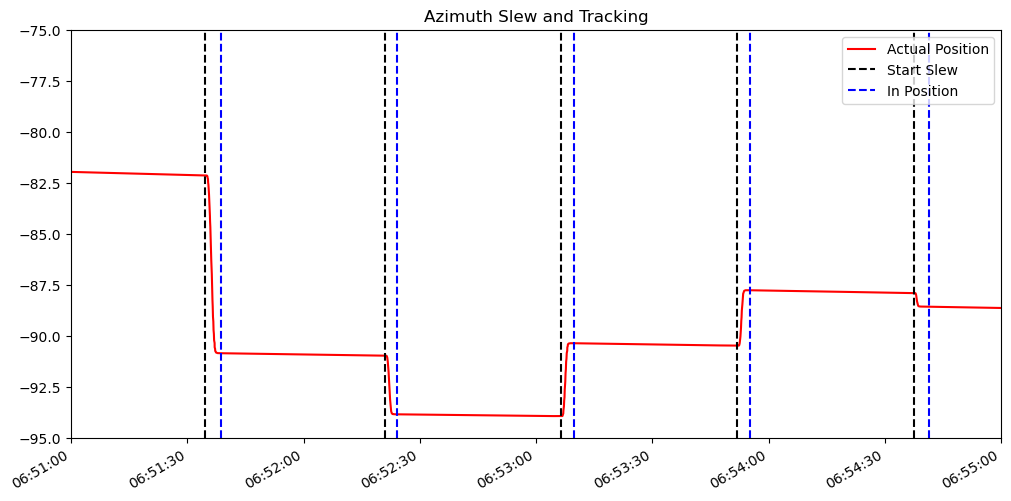

In [32]:
# Plot azimuth position with slew start and in-position timestamps
delta1 = 0
delta = 240

az_pos_values = az_pos.values[:,1]

plt.figure(figsize=(12, 6))
plt.title("Azimuth Slew and Tracking")

ax1 = az['actualPosition'].plot(color='red', label='Actual Position')

# Plot vertical lines for slew start times
for start_slew_time in start_slew_times:
    ss_time = Time(start_slew_time, format='unix_tai', scale='utc').isot
    ax1.axvline(ss_time, color="black", linestyle="--")
    
# Plot vertical lines for in-position times
for in_pos_time in in_pos_1:
    ip_time = Time(in_pos_time, format='unix_tai', scale='utc').isot
    ax1.axvline(ip_time, color="blue", linestyle="--")


# Set limits and labels
ax1.set_xlim(
    (start + TimeDelta(delta1, format='sec')).isot,
    (start + TimeDelta(delta, format='sec')).isot
)
ax1.set_ylim(-95, -75)

# Add legend after plotting lines to capture labels correctly
ax1.axvline(ss_time, color="black", linestyle="--", label="Start Slew")
ax1.axvline(ip_time, color="blue", linestyle="--", label="In Position")
ax1.legend()

plt.show()


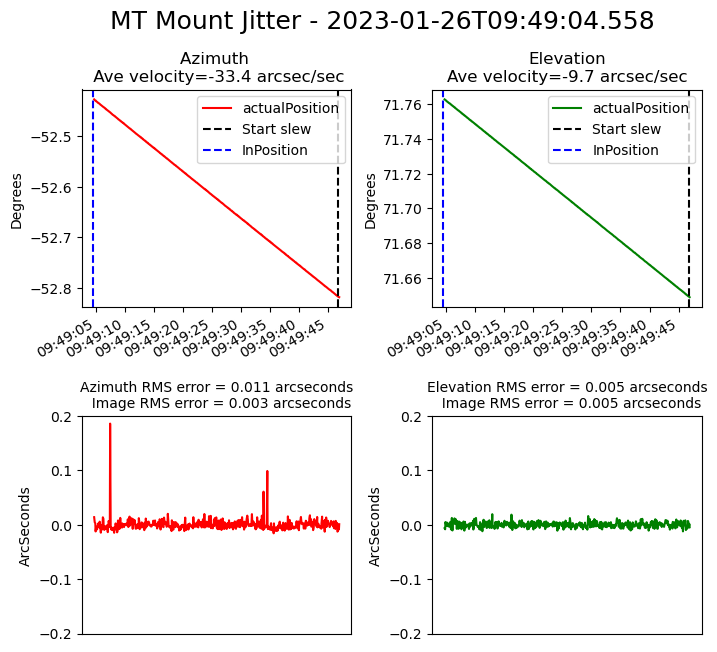

In [33]:
# Plotting the mount plots
az_rms_vals = []
el_rms_vals = []
im_rms_vals = []

fig = plt.figure(figsize = (8, 8))

for index in range(len(in_pos) - 1):
    
    plot_az = az[(az['timestamp'] > in_pos[index]) & (az['timestamp'] < start_slew_times[index+1])]
    plot_el = el[(el['timestamp'] > in_pos[index]) & (el['timestamp'] < start_slew_times[index+1])]
    
    ss_time = Time(start_slew_times[index+1], format='unix_tai', scale='utc').isot
    ip_time = Time(in_pos[index], format='unix_tai', scale='utc').isot

    # Calculate the tracking errors
    az_vals = np.array(plot_az.values[:, 0])
    el_vals = np.array(plot_el.values[:, 0])
    times_az = plot_az.values[:, 1]
    times_el = plot_el.values[:, 1]
    
    # The fits are much better if the time variable
    # is centered in the interval
    time_delta_az = times_az[len(times_az) // 2]
    time_delta_el = times_el[len(times_el) // 2]
    fit_times_az = [t - time_delta_az for t in times_az]
    fit_times_el = [t - time_delta_el for t in times_el]

    # Fit with a polynomial
    az_fit = np.polyfit(fit_times_az, az_vals, 4)
    el_fit = np.polyfit(fit_times_el, el_vals, 4)
    az_model = np.polyval(az_fit, fit_times_az)
    el_model = np.polyval(el_fit, fit_times_el)

    # Errors in arcseconds
    az_error = (az_vals - az_model) * 3600
    el_error = (el_vals - el_model) * 3600
    
    # Drive velocities
    az_vel = (az_model[-1] - az_model[0]) / (fit_times_az[-1] - fit_times_az[0]) * 3600.0
    el_vel = (el_model[-1] - el_model[0]) / (fit_times_el[-1] - fit_times_el[0]) * 3600.0
    
    # Calculate RMS
    az_rms = np.sqrt(np.mean(az_error * az_error))
    el_rms = np.sqrt(np.mean(el_error * el_error))
    az_rms_vals.append(az_rms)
    el_rms_vals.append(el_rms)
    
    # Calculate Image impact RMS
    # We are less sensitive to Az errors near the zenith
    image_az_rms = az_rms * np.cos(np.radians(el_vals[0]))
    image_el_rms = el_rms
    im_rms_vals.append(np.sqrt(image_az_rms**2 + image_el_rms**2))

    fig.clear()
    plt.subplots_adjust(wspace=0.3, hspace=0.5)
    plt.suptitle(f"MT Mount Jitter - {ip_time}", fontsize=18)
    
    plt.subplot(2, 2, 1)
    ax1 = plot_az['actualPosition'].plot(legend=True, color='red')
    ax1.axvline(ss_time, color="black", linestyle="--", label="Start slew")
    ax1.axvline(ip_time, color="blue", linestyle="--", label="InPosition")
    ax1.set_title(f"Azimuth \n Ave velocity={az_vel:.1f} arcsec/sec")
    ax1.set_ylabel("Degrees")
    ax1.legend()
    
    plt.subplot(2, 2, 2)
    ax3 = plot_el['actualPosition'].plot(legend=True, color='green')
    ax3.axvline(ss_time, color="black", linestyle="--", label="Start slew")
    ax3.axvline(ip_time, color="blue", linestyle="--", label="InPosition")
    ax3.set_title(f"Elevation\nAve velocity={el_vel:.1f} arcsec/sec")
    ax3.set_ylabel("Degrees")
    ax3.legend()
    
    plt.subplot(2, 2, 3)
    plt.plot(fit_times_az, az_error, color='red')
    plt.title(f"Azimuth RMS error = {az_rms:.3f} arcseconds\n"
              f"  Image RMS error = {image_az_rms:.3f} arcseconds", fontsize=10)
    
    plt.ylim(-0.2, 0.2)
    plt.xticks([])
    plt.ylabel("ArcSeconds")
    
    plt.subplot(2, 2, 4)
    plt.plot(fit_times_el, el_error, color='green')
    plt.title(f"Elevation RMS error = {el_rms:.3f} arcseconds\n"
              f"  Image RMS error = {image_el_rms:.3f} arcseconds", fontsize=10)
    
    plt.ylim(-0.2, 0.2)
    plt.xticks([])
    plt.ylabel("ArcSeconds")
    timestamp = ip_time.split('.')[0].replace('-','').replace(':','')


# Store results in a dictionary
mount_data = {
    'start_slew_times': start_slew_times,
    'in_pos': in_pos,
    'slew_times': slew_times,
    'slew_dist': slew_dist,
    'az_rms_vals': az_rms_vals,
    'el_rms_vals': el_rms_vals,
    'im_rms_vals': im_rms_vals,
}


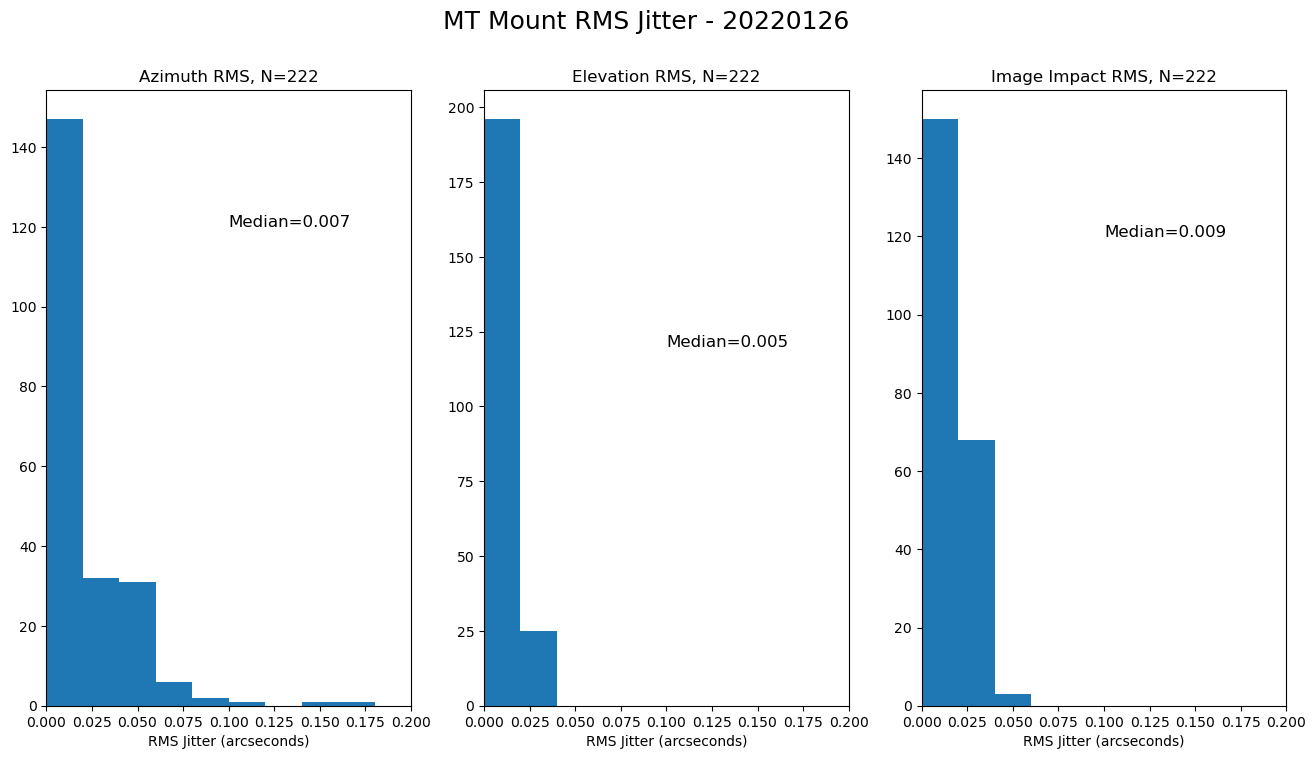

In [34]:
# Summary histograms of mount RMS jitter on 2022-01-26
fig = plt.figure(figsize=(16, 8))
plt.suptitle("MT Mount RMS Jitter - 20220126", fontsize=18)

# Extract values
az_rms_vals = mount_data['az_rms_vals']
el_rms_vals = mount_data['el_rms_vals']
im_rms_vals = mount_data['im_rms_vals']

# Compute medians
az_med = np.median(az_rms_vals)
el_med = np.median(el_rms_vals)
im_med = np.median(im_rms_vals)

# Plot: Azimuth RMS jitter
plt.subplots_adjust(wspace=0.2)
plt.subplot(1, 3, 1)
plt.title(f"Azimuth RMS, N={len(az_rms_vals)}")
plt.hist(az_rms_vals, range=(0, 0.2))
plt.text(0.1, 120, f"Median={az_med:.3f}", fontsize=12)
plt.xlim(0, 0.2)
plt.xlabel("RMS Jitter (arcseconds)")

# Plot: Elevation RMS jitter
plt.subplot(1, 3, 2)
plt.title(f"Elevation RMS, N={len(az_rms_vals)}")
plt.hist(el_rms_vals, range=(0,0.2))
plt.text(0.1, 120, f"Median={el_med:.3f}", fontsize=12)
plt.xlim(0, 0.2)
plt.xlabel("RMS Jitter (arcseconds)")

# Plot: Image impact RMS jitter
plt.subplot(1, 3, 3)
plt.title(f"Image Impact RMS, N={len(az_rms_vals)}")
plt.hist(im_rms_vals, range=(0, 0.2))
plt.text(0.1, 120, f"Median={im_med:.3f}", fontsize=12)
plt.xlim(0, 0.2)
plt.xlabel("RMS Jitter (arcseconds)")

plt.show()

In [35]:
# Print timestamps of slews where azimuth RMS jitter exceeds 0.15 arcseconds
in_pos = mount_data['in_pos']

for i in range(len(az_rms_vals)):
    if az_rms_vals[i] > 0.15:
        timestamp = Time(in_pos[i], format='unix_tai', scale='utc').isot
        print(az_rms_vals[i], timestamp)


0.1694537917485292 2023-01-26T08:01:52.932
860.8845750619053 2023-01-26T08:12:35.161
